In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import roc_auc_score as rocauc

import pandas as pd
from rdkit import Chem
from chembl_structure_pipeline import standardizer

# set seed for NumPy
seed=2024
rng = np.random.default_rng(seed)
np.random.seed(seed)

[13:16:24] Initializing Normalizer


In [2]:
# load the data
df = pd.read_csv("herg_input.csv")
df

,Name,Smiles,Property
0,hERG001,Oc1ccc(CCN2CCC(Nc3n(Cc4ccc(F)cc4)c(c5n3)cccc5)...,1
1,hERG002,CC(c1ccc(C(CCCN2CCC(C(c3ccccc3)(c4ccccc4)O)CC2...,1
2,hERG003,OC(Cc1ccc(n2c(c3c(C4CCN(CCN5C(=O)NCC5)CC4)c2)c...,1
3,hERG004,COc1c(OC)cc(c2c1)c(N)nc(N3CCN(C(C4Oc(c5OC4)ccc...,1
4,hERG005,CC(NCCC(c1ccccc1)c2ccccc2)Cc3ccccc3,1
...,...,...,...
680,hERG681,O=C1N(SC(Cl)(Cl)Cl)C(=O)C(C12)CC=CC2,0
681,hERG682,CN1C(CCc2ccc(NS(=O)(=O)C)cc2)=NC(c3c(F)cc(F)cc...,0
682,hERG683,COc1ccc(CN(c2ncccc2)CCN(C)C)cc1,0
683,hERG684,O=C1C2(C3(C(Cl)(C24Cl)C(Cl)(Cl)C(Cl)(C45Cl)C3(...,0


In [3]:
# set standardize function
def standardize_init(smiles):
    try:
        molecule = Chem.MolFromSmiles(smiles)
        m_no_salts = standardizer.get_parent_mol(molecule)
        tostandarize = m_no_salts[0]
        std_mol = standardizer.standardize_mol(tostandarize)
        canonical_smiles = Chem.MolToSmiles(std_mol)
        return canonical_smiles
    except Exception as e:
        print(f"Error processing SMILES: {smiles}")
        print(e)
        return None

## Standardize and Preprocess Smiles data

In [4]:
# Standardize, remove salts, and canonicalize the SMILES column
df['Smiles_stand'] = df['Smiles'].apply(standardize_init)
df.shape 

[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Normalizer
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16:24] Running Uncharger
[13:16

(685, 4)

In [5]:
df

,Name,Smiles,Property,Smiles_stand
0,hERG001,Oc1ccc(CCN2CCC(Nc3n(Cc4ccc(F)cc4)c(c5n3)cccc5)...,1,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1
1,hERG002,CC(c1ccc(C(CCCN2CCC(C(c3ccccc3)(c4ccccc4)O)CC2...,1,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccc...
2,hERG003,OC(Cc1ccc(n2c(c3c(C4CCN(CCN5C(=O)NCC5)CC4)c2)c...,1,O=C(O)Cc1ccc(-n2cc(C3CCN(CCN4CCNC4=O)CC3)c3cc(...
3,hERG004,COc1c(OC)cc(c2c1)c(N)nc(N3CCN(C(C4Oc(c5OC4)ccc...,1,COc1cc2nc(N3CCN(C(=O)C4COc5ccccc5O4)CC3)nc(N)c...
4,hERG005,CC(NCCC(c1ccccc1)c2ccccc2)Cc3ccccc3,1,CC(Cc1ccccc1)NCCC(c1ccccc1)c1ccccc1
...,...,...,...,...
680,hERG681,O=C1N(SC(Cl)(Cl)Cl)C(=O)C(C12)CC=CC2,0,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl
681,hERG682,CN1C(CCc2ccc(NS(=O)(=O)C)cc2)=NC(c3c(F)cc(F)cc...,0,CN1Cc2ccccc2C(c2ccc(F)cc2F)N=C1CCc1ccc(NS(C)(=...
682,hERG683,COc1ccc(CN(c2ncccc2)CCN(C)C)cc1,0,COc1ccc(CN(CCN(C)C)c2ccccn2)cc1
683,hERG684,O=C1C2(C3(C(Cl)(C24Cl)C(Cl)(Cl)C(Cl)(C45Cl)C3(...,0,O=C1C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(...


In [6]:
# Remove duplicates based on SMILES only
df2 = df.drop_duplicates(subset='Smiles_stand')
# Write the output to a new CSV file
#df2.to_csv('hergi_all_preprocessed_out.csv', index=False)

df2

,Name,Smiles,Property,Smiles_stand
0,hERG001,Oc1ccc(CCN2CCC(Nc3n(Cc4ccc(F)cc4)c(c5n3)cccc5)...,1,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1
1,hERG002,CC(c1ccc(C(CCCN2CCC(C(c3ccccc3)(c4ccccc4)O)CC2...,1,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccc...
2,hERG003,OC(Cc1ccc(n2c(c3c(C4CCN(CCN5C(=O)NCC5)CC4)c2)c...,1,O=C(O)Cc1ccc(-n2cc(C3CCN(CCN4CCNC4=O)CC3)c3cc(...
3,hERG004,COc1c(OC)cc(c2c1)c(N)nc(N3CCN(C(C4Oc(c5OC4)ccc...,1,COc1cc2nc(N3CCN(C(=O)C4COc5ccccc5O4)CC3)nc(N)c...
4,hERG005,CC(NCCC(c1ccccc1)c2ccccc2)Cc3ccccc3,1,CC(Cc1ccccc1)NCCC(c1ccccc1)c1ccccc1
...,...,...,...,...
678,hERG679,Nc1nc(c2c(N)n1)nc(N)c(c3ccccc3)n2,0,Nc1nc(N)c2nc(-c3ccccc3)c(N)nc2n1
679,hERG680,CSc1ccc(C2c(c3CN(C)C(OCc4ccc(NS(=O)(=O)C)cc4)=...,0,CSc1ccc(C2N=C(OCc3ccc(NS(C)(=O)=O)cc3)N(C)Cc3c...
680,hERG681,O=C1N(SC(Cl)(Cl)Cl)C(=O)C(C12)CC=CC2,0,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl
681,hERG682,CN1C(CCc2ccc(NS(=O)(=O)C)cc2)=NC(c3c(F)cc(F)cc...,0,CN1Cc2ccccc2C(c2ccc(F)cc2F)N=C1CCc1ccc(NS(C)(=...


## Extract features from smiles data

In [7]:
from rdkit.Chem import Descriptors

In [8]:
# Define a function to calculate the molecular properties
def calc_mol_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    logP = Descriptors.MolLogP(mol)
    MW = Descriptors.MolWt(mol)
    rotB = Descriptors.NumRotatableBonds(mol)
    HBA = Descriptors.NumHAcceptors(mol)
    HBD = Descriptors.NumHDonors(mol)
    nRING = Descriptors.RingCount(mol)
    TPSA = Descriptors.TPSA(mol)
    
    return pd.Series([logP, MW, rotB, HBA, HBD, nRING, TPSA])

In [9]:
data=df2.copy()
# Calculate molecular properties for each compound
data[["logP", "MW", "rotB", "HBA", "HBD", "nRING", "TPSA"]] = data["Smiles_stand"].apply(calc_mol_properties)

# Write out molecular properties to generate boxplots
#data.to_csv("hergi_all_7molrpop.csv", index=False)
data

,Name,Smiles,Property,Smiles_stand,logP,MW,rotB,HBA,HBD,nRING,TPSA
0,hERG001,Oc1ccc(CCN2CCC(Nc3n(Cc4ccc(F)cc4)c(c5n3)cccc5)...,1,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,5.0483,444.554,7.0,5.0,2.0,5.0,53.32
1,hERG002,CC(c1ccc(C(CCCN2CCC(C(c3ccccc3)(c4ccccc4)O)CC2...,1,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccc...,6.4458,471.685,8.0,3.0,2.0,4.0,43.70
2,hERG003,OC(Cc1ccc(n2c(c3c(C4CCN(CCN5C(=O)NCC5)CC4)c2)c...,1,O=C(O)Cc1ccc(-n2cc(C3CCN(CCN4CCNC4=O)CC3)c3cc(...,4.1156,480.996,7.0,4.0,2.0,5.0,77.81
3,hERG004,COc1c(OC)cc(c2c1)c(N)nc(N3CCN(C(C4Oc(c5OC4)ccc...,1,COc1cc2nc(N3CCN(C(=O)C4COc5ccccc5O4)CC3)nc(N)c...,1.7178,451.483,4.0,9.0,1.0,5.0,112.27
4,hERG005,CC(NCCC(c1ccccc1)c2ccccc2)Cc3ccccc3,1,CC(Cc1ccccc1)NCCC(c1ccccc1)c1ccccc1,5.4294,329.487,8.0,1.0,1.0,3.0,12.03
...,...,...,...,...,...,...,...,...,...,...,...
678,hERG679,Nc1nc(c2c(N)n1)nc(N)c(c3ccccc3)n2,0,Nc1nc(N)c2nc(-c3ccccc3)c(N)nc2n1,0.8334,253.269,1.0,7.0,3.0,3.0,129.62
679,hERG680,CSc1ccc(C2c(c3CN(C)C(OCc4ccc(NS(=O)(=O)C)cc4)=...,0,CSc1ccc(C2N=C(OCc3ccc(NS(C)(=O)=O)cc3)N(C)Cc3c...,4.8876,481.643,6.0,6.0,1.0,4.0,71.00
680,hERG681,O=C1N(SC(Cl)(Cl)Cl)C(=O)C(C12)CC=CC2,0,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl,2.9135,300.594,1.0,3.0,0.0,2.0,37.38
681,hERG682,CN1C(CCc2ccc(NS(=O)(=O)C)cc2)=NC(c3c(F)cc(F)cc...,0,CN1Cc2ccccc2C(c2ccc(F)cc2F)N=C1CCc1ccc(NS(C)(=...,4.9024,469.557,6.0,4.0,1.0,4.0,61.77


In [10]:
from rdkit.Chem import AllChem
#from sklearn.naive_bayes import GaussianNB
#import pickle
#from joblib import dump



In [11]:
def morgan_fingerprint(smiles, radius, nBits):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    return np.array(fp, dtype=np.int8)

In [12]:
# Load dataset
#data = pd.read_csv("hergi_all_preprocessed_out.csv")
#df = data[["Name", "Smiles_stand", "Property"]]

# Convert SMILES to Morgan fingerprints
data['Fingerprint'] = df['Smiles_stand'].apply(morgan_fingerprint, radius=2, nBits=1024)



In [13]:
data

,Name,Smiles,Property,Smiles_stand,logP,MW,rotB,HBA,HBD,nRING,TPSA,Fingerprint
0,hERG001,Oc1ccc(CCN2CCC(Nc3n(Cc4ccc(F)cc4)c(c5n3)cccc5)...,1,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,5.0483,444.554,7.0,5.0,2.0,5.0,53.32,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,hERG002,CC(c1ccc(C(CCCN2CCC(C(c3ccccc3)(c4ccccc4)O)CC2...,1,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccc...,6.4458,471.685,8.0,3.0,2.0,4.0,43.70,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,hERG003,OC(Cc1ccc(n2c(c3c(C4CCN(CCN5C(=O)NCC5)CC4)c2)c...,1,O=C(O)Cc1ccc(-n2cc(C3CCN(CCN4CCNC4=O)CC3)c3cc(...,4.1156,480.996,7.0,4.0,2.0,5.0,77.81,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,hERG004,COc1c(OC)cc(c2c1)c(N)nc(N3CCN(C(C4Oc(c5OC4)ccc...,1,COc1cc2nc(N3CCN(C(=O)C4COc5ccccc5O4)CC3)nc(N)c...,1.7178,451.483,4.0,9.0,1.0,5.0,112.27,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,hERG005,CC(NCCC(c1ccccc1)c2ccccc2)Cc3ccccc3,1,CC(Cc1ccccc1)NCCC(c1ccccc1)c1ccccc1,5.4294,329.487,8.0,1.0,1.0,3.0,12.03,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
678,hERG679,Nc1nc(c2c(N)n1)nc(N)c(c3ccccc3)n2,0,Nc1nc(N)c2nc(-c3ccccc3)c(N)nc2n1,0.8334,253.269,1.0,7.0,3.0,3.0,129.62,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
679,hERG680,CSc1ccc(C2c(c3CN(C)C(OCc4ccc(NS(=O)(=O)C)cc4)=...,0,CSc1ccc(C2N=C(OCc3ccc(NS(C)(=O)=O)cc3)N(C)Cc3c...,4.8876,481.643,6.0,6.0,1.0,4.0,71.00,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
680,hERG681,O=C1N(SC(Cl)(Cl)Cl)C(=O)C(C12)CC=CC2,0,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl,2.9135,300.594,1.0,3.0,0.0,2.0,37.38,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
681,hERG682,CN1C(CCc2ccc(NS(=O)(=O)C)cc2)=NC(c3c(F)cc(F)cc...,0,CN1Cc2ccccc2C(c2ccc(F)cc2F)N=C1CCc1ccc(NS(C)(=...,4.9024,469.557,6.0,4.0,1.0,4.0,61.77,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [14]:
feats=['finger_'+str(k) for k in range(1,1025)]

col=["logP", "MW", "rotB", "HBA", "HBD", "nRING", "TPSA"]

for f in col: feats.append(f)

In [15]:
# Stack the fingerprint arrays into a 2D numpy array
X = np.stack(data['Fingerprint'].values)

In [16]:
for f in range(len(col)):
    X=np.append(X,data.loc[:,col[f]].values.reshape(-1,1),axis=1)

print(X.shape)
# Split into input features and output variable
y = data['Property'].values

(662, 1031)


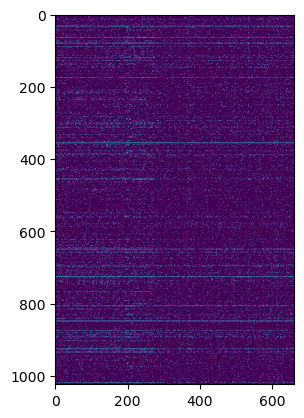

In [17]:
plt.imshow(X[:,:1024].T)
plt.show()

In [18]:
# Train-Test split
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.4,random_state=seed)
print(X_train.shape,X_test.shape)

(397, 1031) (265, 1031)


## Univariate analysis
AUC of features against the property (1 - drug is a hERG blocker and must be avoided, 0 - no effect)

Strictly use only the train set from here on. Also note that we have only 397 samples and 1031 features so false associations in multivariate models is a certainity. Hence Univariate analysis to pre-select reasonably predictive features and feature clustering to reduce correlated ones are important steps in model development.

In [19]:
# Univariate analysis
feats=np.array(feats)
Nfeats=len(feats)
auc=np.zeros((Nfeats,))
for k in range(Nfeats):
    auc[k]=rocauc(y_train,X_train[:,k])
    if(auc[k]<0.5): auc[k]=1-auc[k]

ik=auc>0.65 # find weakly predictive features

print(feats[ik])
print(auc[ik])

['finger_122' 'finger_302' 'finger_457' 'finger_768' 'finger_927'
 'finger_936' 'finger_1020' 'MW' 'nRING']
[0.65346305 0.67712634 0.70668611 0.65935952 0.72184661 0.75229666
 0.67663604 0.79123658 0.81238388]


In [20]:
ik=auc>0.6 # find weakly predictive features

print(feats[ik])
print(auc[ik])

['finger_91' 'finger_122' 'finger_238' 'finger_302' 'finger_315'
 'finger_387' 'finger_457' 'finger_647' 'finger_700' 'finger_727'
 'finger_768' 'finger_876' 'finger_905' 'finger_927' 'finger_936'
 'finger_1020' 'logP' 'MW' 'rotB' 'HBA' 'nRING']
[0.60750413 0.65346305 0.62559352 0.67712634 0.60473008 0.61732298
 0.70668611 0.616923   0.61062655 0.61080718 0.65935952 0.62672894
 0.64951486 0.72184661 0.75229666 0.67663604 0.64581183 0.79123658
 0.63374794 0.62487097 0.81238388]


In [21]:
np.sum(y_train)

173

In [22]:
ik=auc>0.7 # find predictive features

print(feats[ik])
print(auc[ik])

['finger_457' 'finger_927' 'finger_936' 'MW' 'nRING']
[0.70668611 0.72184661 0.75229666 0.79123658 0.81238388]


In [23]:
# try simple logistic regression for the 5 features first
from sklearn.linear_model import LogisticRegressionCV as logregcv

lmod=logregcv(cv=10,scoring='neg_log_loss',max_iter=100000,class_weight='balanced',random_state=seed,n_jobs=-1,
             penalty='elasticnet',solver='saga',l1_ratios=[0.5,0.8,0.85,0.9,0.95,0.98,1.0])
#
lmod.fit(X_train[:,ik],y_train)

LogisticRegressionCV(class_weight='balanced', cv=10,
                     l1_ratios=[0.5, 0.8, 0.85, 0.9, 0.95, 0.98, 1.0],
                     max_iter=100000, n_jobs=-1, penalty='elasticnet',
                     random_state=2024, scoring='neg_log_loss', solver='saga')

In [24]:
print(lmod.coef_*X_train[:,ik].mean(axis=0),lmod.intercept_)

[[ 0.04242884  0.05599904  0.07701547 -0.7897827   0.98507192]] [-0.1820831]


In [25]:
summary=pd.DataFrame([],columns=['Model','Parameters','Train-AUC','Test-AUC'])
ypred_tr=lmod.predict_proba(X_train[:,ik])
ypred_te=lmod.predict_proba(X_test[:,ik])
summary.loc[len(summary.index),:]=['Logistic',np.sum(ik),rocauc(y_train,ypred_tr[:,1]),rocauc(y_test,ypred_te[:,1])]

summary
                            

,Model,Parameters,Train-AUC,Test-AUC
0,Logistic,5,0.794398,0.706283


In [26]:
ids=np.where(ik)[0]
ids

array([ 456,  926,  935, 1025, 1029], dtype=int64)

In [27]:
# select the top 2 important features as found from the logmodel coefficients and just train on those
from sklearn.linear_model import LogisticRegression as logreg

lmod_basic=logreg(class_weight='balanced', random_state=seed, max_iter=100000)

lmod_basic.fit(X_train[:,ids[-2:]],y_train)


LogisticRegression(class_weight='balanced', max_iter=100000, random_state=2024)

In [28]:
ypred_tr=lmod_basic.predict_proba(X_train[:,ids[-2:]])
ypred_te=lmod_basic.predict_proba(X_test[:,ids[-2:]])
summary.loc[len(summary.index),:]=['Logistic',2,rocauc(y_train,ypred_tr[:,1]),rocauc(y_test,ypred_te[:,1])]

In [29]:
summary

,Model,Parameters,Train-AUC,Test-AUC
0,Logistic,5,0.794398,0.706283
1,Logistic,2,0.831841,0.773352


In [30]:
from sklearn.metrics import roc_curve

fpr,tpr,threshs=roc_curve(y_train,ypred_tr[:,1])
fprt,tprt,threshst=roc_curve(y_test,ypred_te[:,1])

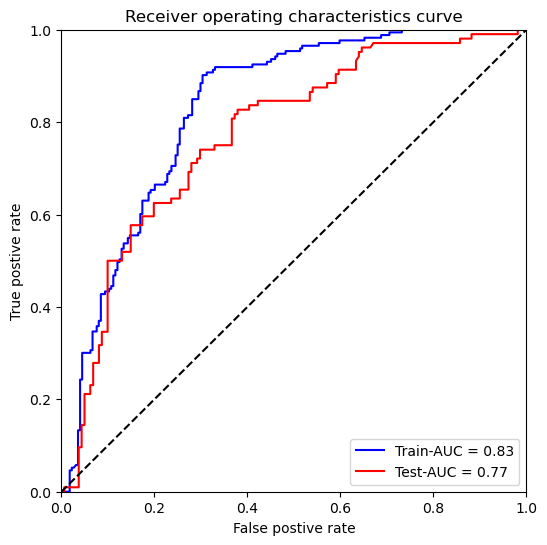

In [31]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, 'b', label = 'Train-AUC = %0.2f' % rocauc(y_train,ypred_tr[:,1]))
plt.plot(fprt, tprt, 'r', label = 'Test-AUC = %0.2f' % rocauc(y_test,ypred_te[:,1]))
plt.plot([0, 1], [0, 1],'k--')
plt.legend(loc='lower right')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False postive rate')
plt.ylabel('True postive rate')
plt.title('Receiver operating characteristics curve')
plt.show()

In [36]:

lmod_basic=logreg(class_weight='balanced', random_state=seed, max_iter=100000)

lmod_basic.fit(X_train[:,ids[1:-2]],y_train)

LogisticRegression(class_weight='balanced', max_iter=100000, random_state=2024)

In [37]:
print(lmod_basic.coef_*X_train[:,ids[1:-2]].mean(axis=0),lmod_basic.intercept_)

[[0.61714944 0.73563805]] [-1.44787452]


In [38]:
ypred_tr=lmod_basic.predict_proba(X_train[:,ids[1:-2]])
ypred_te=lmod_basic.predict_proba(X_test[:,ids[1:-2]])
summary.loc[len(summary.index),:]=['Logistic-Finger',2,rocauc(y_train,ypred_tr[:,1]),rocauc(y_test,ypred_te[:,1])]

In [39]:
summary

,Model,Parameters,Train-AUC,Test-AUC
0,Logistic,5,0.794398,0.706283
1,Logistic,2,0.831841,0.773352
2,Logistic-Finger,3,0.798914,0.714495
3,Logistic-Finger,2,0.792927,0.714465


In [40]:
ik=auc>0.65 # find weakly predictive features
ids=np.where(ik)[0]
print(feats[ik])
print(auc[ik])

['finger_122' 'finger_302' 'finger_457' 'finger_768' 'finger_927'
 'finger_936' 'finger_1020' 'MW' 'nRING']
[0.65346305 0.67712634 0.70668611 0.65935952 0.72184661 0.75229666
 0.67663604 0.79123658 0.81238388]


In [41]:
lmod=logregcv(cv=10,scoring='neg_log_loss',max_iter=100000,class_weight='balanced',random_state=seed,n_jobs=-1,
             penalty='elasticnet',solver='saga',l1_ratios=[0.5,0.8,0.85,0.9,0.95,0.98,1.0])
#
lmod.fit(X_train[:,ids[:-2]],y_train)

LogisticRegressionCV(class_weight='balanced', cv=10,
                     l1_ratios=[0.5, 0.8, 0.85, 0.9, 0.95, 0.98, 1.0],
                     max_iter=100000, n_jobs=-1, penalty='elasticnet',
                     random_state=2024, scoring='neg_log_loss', solver='saga')

In [42]:
print(lmod.coef_*X_train[:,ids[:-2]].mean(axis=0),lmod.intercept_)

[[0.07912079 0.27785178 0.         0.17452786 0.2074389  0.58988755
  0.02993161]] [-1.38616091]


In [43]:
isel=ids[np.array([1,3,4,5])]
isel

array([301, 767, 926, 935], dtype=int64)

In [44]:
lmod_basic=logreg(class_weight='balanced', random_state=seed, max_iter=100000)

lmod_basic.fit(X_train[:,isel],y_train)

LogisticRegression(class_weight='balanced', max_iter=100000, random_state=2024)

In [45]:
print(lmod_basic.coef_*X_train[:,isel].mean(axis=0),lmod_basic.intercept_)

[[0.31900305 0.23199172 0.2225988  0.66758201]] [-1.45165552]


In [46]:
ypred_tr=lmod_basic.predict_proba(X_train[:,isel])
ypred_te=lmod_basic.predict_proba(X_test[:,isel])
summary.loc[len(summary.index),:]=['Logistic-Finger',4,rocauc(y_train,ypred_tr[:,1]),rocauc(y_test,ypred_te[:,1])]
summary

,Model,Parameters,Train-AUC,Test-AUC
0,Logistic,5,0.794398,0.706283
1,Logistic,2,0.831841,0.773352
2,Logistic-Finger,3,0.798914,0.714495
3,Logistic-Finger,2,0.792927,0.714465
4,Logistic-Finger,4,0.82748,0.735457
